In [112]:
import numpy as np


In [113]:
# Required imports

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from numpy import pi, random

In [100]:
qubit = QuantumRegister(1, "Q")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")
a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")

protocol = QuantumCircuit(qubit, ebit0, ebit1, a, b)

# Prepare ebit used for teleportation
protocol.h(ebit0)
protocol.cx(ebit0, ebit1)
protocol.barrier()

# Alice's operations
protocol.cx(qubit, ebit0)
protocol.h(qubit)
protocol.barrier()

# Alice measures and sends classical bits to Bob
protocol.measure(ebit0, a)
protocol.measure(qubit, b)
protocol.barrier()

# Bob uses the classical bits to conditionally apply gates
with protocol.if_test((a, 1)):
    protocol.x(ebit1)
with protocol.if_test((b, 1)):
    protocol.z(ebit1)

display(protocol.draw())

░      ┌───┐ ░    ┌─┐ ░                                     »
  Q: ───────────░───■──┤ H ├─░────┤M├─░─────────────────────────────────────»
     ┌───┐      ░ ┌─┴─┐└───┘ ░ ┌─┐└╥┘ ░                                     »
  A: ┤ H ├──■───░─┤ X ├──────░─┤M├─╫──░─────────────────────────────────────»
     └───┘┌─┴─┐ ░ └───┘      ░ └╥┘ ║  ░ ┌────── ┌───┐ ───────┐ ┌────── ┌───┐»
  B: ─────┤ X ├─░────────────░──╫──╫──░─┤ If-0  ┤ X ├  End-0 ├─┤ If-0  ┤ Z ├»
          └───┘ ░            ░  ║  ║  ░ └──╥─── └───┘ ───────┘ └──╥─── └───┘»
                                ║  ║    ┌──╨──┐                   ║         »
a: 1/═══════════════════════════╩══╬════╡ 0x1 ╞═══════════════════╬═════════»
                                0  ║    └─────┘                ┌──╨──┐      »
b: 1/══════════════════════════════╩═══════════════════════════╡ 0x1 ╞══════»
                                   0                           └─────┘      »
«               
«  Q: ──────────
«               
«  A: ──────────
«      ───────┐ 
«  B:   End-0 ├─
«      ───────┘ 
«a: 1/══════════
«               
«b: 1/══════════
«

In [101]:
random_gate = UGate(
    theta=random.random() * 2 * pi,
    phi=random.random() * 2 * pi,
    lam=random.random() * 2 * pi,
)

display(random_gate.to_matrix())

# Create a new circuit including the same bits and qubits used in the
# teleportation protocol.

test = QuantumCircuit(qubit, ebit0, ebit1, a, b)

# Start with the randomly selected gate on Q

test.append(random_gate, qubit)
test.barrier()

# Append the entire teleportation protocol from above.

test = test.compose(protocol)
test.barrier()

# Finally, apply the inverse of the random unitary to B and measure.

test.append(random_gate.inverse(), ebit1)

result = ClassicalRegister(1, "Result")
test.add_register(result)
test.measure(ebit1, result)

display(test.draw())

array([[-0.35179332+0.j        , -0.21877682+0.91015282j],
       [-0.1346957 -0.92633608j,  0.35032159+0.03214537j]])

┌────────────────────────┐ ░            ░      ┌───┐ ░    ┌─┐ ░ »
       Q: ┤ U(3.8606,4.568,4.9483) ├─░────────────░───■──┤ H ├─░────┤M├─░─»
          └────────────────────────┘ ░ ┌───┐      ░ ┌─┴─┐└───┘ ░ ┌─┐└╥┘ ░ »
       A: ───────────────────────────░─┤ H ├──■───░─┤ X ├──────░─┤M├─╫──░─»
                                     ░ └───┘┌─┴─┐ ░ └───┘      ░ └╥┘ ║  ░ »
       B: ───────────────────────────░──────┤ X ├─░────────────░──╫──╫──░─»
                                     ░      └───┘ ░            ░  ║  ║  ░ »
     a: 1/════════════════════════════════════════════════════════╩══╬════»
                                                                  0  ║    »
     b: 1/═══════════════════════════════════════════════════════════╩════»
                                                                     0    »
Result: 1/════════════════════════════════════════════════════════════════»
                                                                          »
«                                                         ░ »
«       Q: ───────────────────────────────────────────────░─»
«                                                         ░ »
«       A: ───────────────────────────────────────────────░─»
«          ┌────── ┌───┐ ───────┐ ┌────── ┌───┐ ───────┐  ░ »
«       B: ┤ If-0  ┤ X ├  End-0 ├─┤ If-0  ┤ Z ├  End-0 ├──░─»
«          └──╥─── └───┘ ───────┘ └──╥─── └───┘ ───────┘  ░ »
«          ┌──╨──┐                   ║                      »
«     a: 1/╡ 0x1 ╞═══════════════════╬══════════════════════»
«          └─────┘                ┌──╨──┐                   »
«     b: 1/═══════════════════════╡ 0x1 ╞═══════════════════»
«                                 └─────┘                   »
«Result: 1/═════════════════════════════════════════════════»
«                                                           »
«                                          
«       Q: ────────────────────────────────
«                                          
«       A: ────────────────────────────────
«          ┌───────────────────────────┐┌─┐
«       B: ┤ U(-3.8606,-4.9483,-4.568) ├┤M├
«          └───────────────────────────┘└╥┘
«     a: 1/══════════════════════════════╬═
«                                        ║ 
«     b: 1/══════════════════════════════╬═
«                                        ║ 
«Result: 1/══════════════════════════════╩═
«                                        0

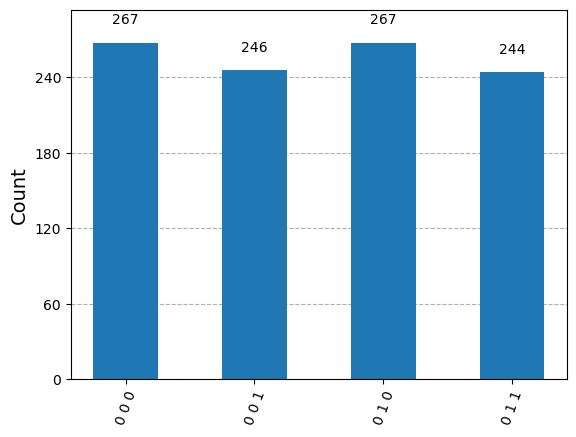

In [102]:
result = AerSimulator().run(test).result()
statistics = result.get_counts()
display(plot_histogram(statistics))

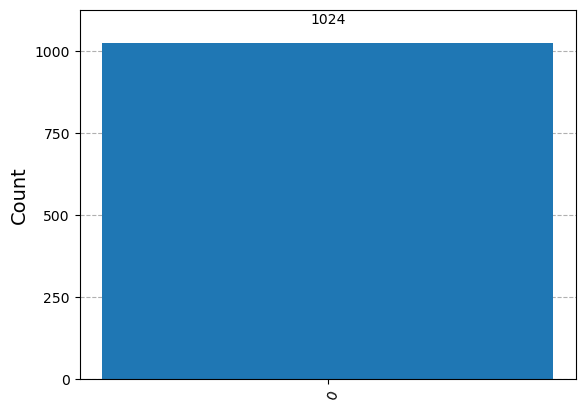

In [103]:
filtered_statistics = marginal_distribution(statistics, [2])
display(plot_histogram(filtered_statistics))

In [98]:
import numpy as np

q0 = np.array([1, 0])
q1 = np.array([0, 1])
H = np.array([[1, 1], [1, -1]]) / np.sqrt(2)
CNOT = np.array([[1, 0, 0, 0],
                 [0, 1, 0, 0],
                 [0, 0, 0, 1],
                 [0, 0, 1, 0]])
I = np.eye(2)

inital_state = np.kron(q0, q1)
print(inital_state)

# Apply H to first qubit
step_1 = np.kron(H, I) @ inital_state

print(step_1)
# Apply CNOT
step_2 = CNOT @ step_1

print(step_2)

[0 1 0 0]
[0.         0.70710678 0.         0.70710678]
[0.         0.70710678 0.70710678 0.        ]


In [13]:
ket_0 = np.array([[1], [0], [0]])
ket_1 = np.array([[0], [1], [0]])
ket_2 = np.array([[0], [0], [1]])


print(np.dot(ket_0, ket_0.T) + np.dot(ket_1, ket_1.T) + np.dot(ket_2, ket_2.T))
print((ket_0 + ket_1 + ket_2) * (ket_0.T + ket_1.T + ket_2.T))

[[1 0 0]
 [0 1 0]
 [0 0 1]]
[[1 1 1]
 [1 1 1]
 [1 1 1]]


In [31]:
# print(
#     (2*ket_0 - ket_1) * 
#     (-9*ket_0.T+ 3*ket_1.T) )
# print(2*ket_0*ket_0.T-ket_0*ket_1.T-9*ket_1*ket_0.T+3*ket_1*ket_1.T)

# print(
#     (2*ket_1*ket_1.T)
#     - (ket_0*ket_1.T)
#     - (9*ket_1*ket_0.T)
#     + (3*ket_0*ket_0.T)
# )

# print(
#     (2*ket_0*ket_0.T)
#     - (ket_1*ket_0.T)
#     - (9*ket_0*ket_1.T)
#     + (3*ket_1*ket_1.T)
# )

ket_00 = np.kron(ket_0, ket_0)
ket_11 = np.kron(ket_1, ket_1)
ket_01 = np.kron(ket_0, ket_1)
ket_10 = np.kron(ket_1, ket_0)
print(2*ket_00*ket_00.T)

[[2 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]]


In [42]:
from numpy import sqrt
from qiskit.quantum_info import Statevector
sv=Statevector(
    [
        (1j-sqrt(3))/(2*sqrt(3)),
        (1-1j)/(sqrt(12)),
        (1)/(sqrt(2)),
])
sv.is_valid()

True

In [43]:
sv=Statevector(
    [
        (sqrt(6))/2,
        (sqrt(2))/(2),
        (2*1j)/(2),
])
sv.is_valid()

False

In [44]:
sv=Statevector(
    [
        (1j)/sqrt(3),
        (1)/(sqrt(2)),
        (1)/(sqrt(6)),
])
sv.is_valid()

True

In [45]:
sv=Statevector(
    [
        (sqrt(2))/(2),
        (sqrt(2/3))/2,
        (2*1j)/(2*sqrt(3)),
])
sv.is_valid()

True

In [56]:
u = Statevector([-2, 1])
v = Statevector([1, 0, 1])
w = Statevector([8/3, 2/3])
x = Statevector([1/2, 1/2, 1/2])

op = u.tensor(v) - (w.tensor(x))
op

Statevector([-3.33333333+0.j, -1.33333333+0.j, -3.33333333+0.j,
              0.66666667+0.j, -0.33333333+0.j,  0.66666667+0.j],
            dims=(3, 2))


In [57]:
zero, one = Statevector.from_label("0"), Statevector.from_label("1")
zero.tensor(one).draw("latex")

<IPython.core.display.Latex object>

In [128]:
from qiskit.quantum_info import Operator

from qiskit import QuantumCircuit, transpile, assemble
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_state_city
import qiskit.quantum_info as qi

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

X = QuantumRegister(1, "X")
Y = QuantumRegister(1, "Y")

circuit = QuantumCircuit(Y, X)
circuit.x(X)
circuit.h(Y)
circuit.save_statevector(label=f'psi_1')
circuit.cx(Y, X)
circuit.save_statevector(label=f'psi_2')
circuit.z(X)
circuit.cx(X, Y)
circuit.h(X)

circuit.save_statevector(label=f'psi_3')

display(circuit.draw())

# Transpile for simulator
simulator = AerSimulator(method = 'statevector')
circ = transpile(circuit, simulator)

result = simulator.run(circ).result()

result.data(0)['psi_1'].draw("latex")

┌───┐ psi_1       psi_2      ┌───┐      psi_3 
Y: ┤ H ├───░─────■─────░────────┤ X ├────────░───
   ├───┤   ░   ┌─┴─┐   ░   ┌───┐└─┬─┘┌───┐   ░   
X: ┤ X ├───░───┤ X ├───░───┤ Z ├──■──┤ H ├───░───
   └───┘   ░   └───┘   ░   └───┘     └───┘   ░

<IPython.core.display.Latex object>

In [127]:
from qiskit.quantum_info import Operator

from qiskit import QuantumCircuit, transpile, assemble
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_state_city
import qiskit.quantum_info as qi

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

Y = QuantumRegister(1, "Y")
X = QuantumRegister(1, "X")


circuit = QuantumCircuit(Y, X)
circuit.x(Y)
circuit.s(X)
circuit.cx(X, Y)
circuit.h(Y)
circuit.h(X)

circuit.save_unitary()

display(circuit.draw())

simulator = AerSimulator(method = 'unitary')
circ = transpile(circuit, simulator)

result = simulator.run(circ).result()
result.get_unitary(decimals=3)

┌───┐┌───┐┌───┐ unitary 
Y: ┤ X ├┤ X ├┤ H ├────░────
   ├───┤└─┬─┘├───┤    ░    
X: ┤ S ├──■──┤ H ├────░────
   └───┘     └───┘    ░

Operator([[ 0.5-0.j ,  0.5+0.j ,  0. +0.5j,  0. +0.5j],
          [-0.5+0.j ,  0.5+0.j ,  0. +0.5j, -0. -0.5j],
          [ 0.5-0.j ,  0.5+0.j , -0. -0.5j, -0. -0.5j],
          [-0.5+0.j ,  0.5+0.j , -0. -0.5j,  0. +0.5j]],
         input_dims=(2, 2), output_dims=(2, 2))


In [77]:
import qiskit
print(qiskit.version.get_version_info())

1.1.1


In [134]:

statevector1=Statevector(
    [5/13, 12/13])
statevector2=Statevector(
    [12/13, -5/13])

inner_product = statevector1.inner(statevector2)

print("Inner product:", inner_product)

Inner product: (-2.6277468038465255e-18+0j)


In [47]:
from qiskit import QuantumCircuit, transpile, assemble
from qiskit.visualization import plot_bloch_vector
from qiskit.quantum_info import Statevector
from numpy import pi

# Create a quantum circuit with 1 qubit
qc = QuantumCircuit(1)

# Apply rotations to the qubit (example of X, Y, Z rotation gates)
qc.rx(pi/3, 0)  # Rotation around X-axis
qc.ry(pi/4, 0)  # Rotation around Y-axis
qc.rz(pi/6, 0)  # Rotation around Z-axis

# Visualize the Bloch vector
# Extract the state vector
state = Statevector.from_instruction(qc)

# Get the Bloch vector
bloch_vector = state
print(bloch_vector)

# Plot Bloch vector on the Bloch sphere
plot_bloch_vector(bloch_vector, title="Bloch Sphere Representation")


ImportError: cannot import name 'BasicAer' from 'qiskit' (/opt/conda/lib/python3.11/site-packages/qiskit/__init__.py)

Statevector([0.82236317-0.02226003j, 0.43967974-0.36042341j],
            dims=(2,))


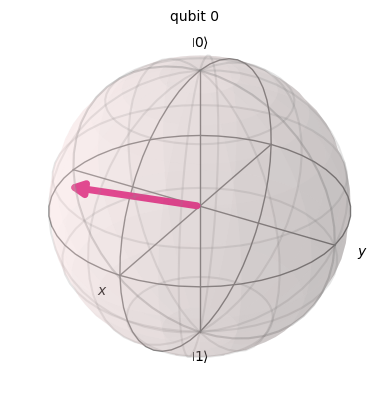

In [43]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_bloch_multivector
from numpy import pi
%matplotlib inline
 
qc = QuantumCircuit(1)
qc.rx(np.pi/3, 0)  # Rotation around X-axis
qc.ry(np.pi/4, 0)  # Rotation around Y-axis
qc.rz(np.pi/6, 0)  # Rotation around Z-axis

# qc.cx(0, 1)


sv = qiskit.quantum_info.Statevector.from_instruction(qc)
print(sv)
plot_bloch_multivector(sv)

[[0.8660254]
 [0.5      ]]
0.7499999999999999
0.25


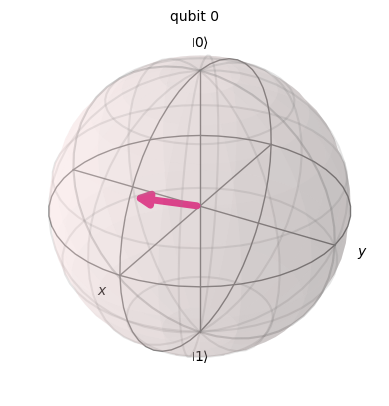

In [24]:
import qiskit
from qiskit.visualization import plot_bloch_multivector

q0 = np.array([[np.sqrt(3)/2],
               [1/2]])

alfa = np.absolute((np.sqrt(3)/2)**2)
beta = np.absolute((1/2)**2)
ket0 = np.array([1, 0])
ket1 = np.array([0, 1])
vectorAlfa = np.array([np.sqrt(3)/2, np.sqrt(3)/2])

print(q0)
print(alfa)
print(beta)


alpha = np.sqrt(3)/2
beta = 1/2
state_vector = [alpha, beta]
qc = QuantumCircuit(1)
qc.initialize(state_vector,0)

# 60 Grados

sv = qiskit.quantum_info.Statevector.from_instruction(qc)
#print(sv)
plot_bloch_multivector(sv)

In [76]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_bloch_multivector
from numpy import pi
import math

print(math.degrees(pi/4))


y = pi/4
# x = -(pi/2 + pi/4)
qc = QuantumCircuit(1)
qc.rx(y, 0)
qc.rz(y, 0)
qc.save_statevector(label=f'z')
qc.x(0)
qc.save_statevector(label=f'x')
# qc.rx(np.pi/3, 0)  # Rotation around X-axis
# qc.ry(np.pi/4, 0)  # Rotation around Y-axis
# qc.rz(np.pi/6, 0)  # Rotation around Z-axis

# qc.cx(0, 1) [0.70710678+0.j        , 0.        -0.70710678j]
# opuesto [0.70710678+0.j        , 0.        +0.70710678j]


# sv = qiskit.quantum_info.Statevector.from_instruction(qc)
print(qc)
# plot_bloch_multivector(sv)

45.0
   ┌─────────┐┌─────────┐ z ┌───┐ x 
q: ┤ Rx(π/4) ├┤ Rz(π/4) ├─░─┤ X ├─░─
   └─────────┘└─────────┘ ░ └───┘ ░ 


In [82]:
from qiskit.quantum_info import Statevector, Operator

def transform_qBit(theta, phi):
    qr=QuantumRegister(1)
    qc=QuantumCircuit(qr)
    qc.u(theta,phi,pi/2,qr[0]) 
    return Statevector.from_instruction(qc)

#change your parameters here, first one is theta second one is phi
v = transform_qBit(pi/2, pi/2)
v.draw("latex")

<IPython.core.display.Latex object>

In [87]:
v = transform_qBit(pi/2, pi)
v.draw("latex")
# plot_bloch_multivector(v)

<IPython.core.display.Latex object>

In [252]:
c_zero = np.complex128(0)

ket_zero = np.array([c_zero, c_zero])
H = np.array([[1, 1], [1, -1]]) / np.sqrt(2)
H_gate = 1/np.sqrt(2.0) * np.array([[1,1],[1,-1]])
CX = np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]])
I = np.array([[1,0],[0,1]])
X = np.array([[0,1],[1,0]])

H_gate@ket_zero

array([0.+0.j, 0.+0.j])

In [263]:
import numpy as np

def apply_hadamard_to_n_qubits(n):
    H = (1/np.sqrt(2)) * np.array([[1, 1],
                                    [1, -1]])
    H_n = H
    for _ in range(n - 1):
        H_n = np.kron(H_n, H)
    return H_n

def apply_cnot_chain(state, n_qubits):
    for control in range(n_qubits - 1):
        target = control + 1
        state = apply_cnot(state, n_qubits, control, target)
    return state

def apply_cnot(state, n_qubits, control, target):
    I = np.eye(2)
    CNOT = np.array([[1, 0, 0, 0],
                     [0, 1, 0, 0],
                     [0, 0, 0, 1],
                     [0, 0, 1, 0]])
    
    full_cnot = 1
    for i in range(n_qubits):
        if i == control:
            full_cnot = np.kron(full_cnot, CNOT[:2, :2])
        elif i == target:
            full_cnot = np.kron(full_cnot, CNOT[2:, 2:])
        else:
            full_cnot = np.kron(full_cnot, I)
    
    return full_cnot @ state

def apply_x_to_last_qubit(state, n_qubits):
    # Define the X gate
    X = np.array([[0, 1],
                  [1, 0]])
    # Define the identity matrix
    I = np.eye(2)
    
    # Construct the full matrix with X applied to the last qubit
    full_x = 1
    for i in range(n_qubits):
        if i == n_qubits - 1:
            full_x = np.kron(full_x, X)
        else:
            full_x = np.kron(full_x, I)
    
    # Apply the X gate to the last qubit
    return full_x @ state

# Example usage for 3 qubits
n_qubits = 3
H_n = apply_hadamard_to_n_qubits(n_qubits)

# Define the initial state |000>
initial_state = np.zeros(2**n_qubits, dtype=complex)
initial_state[0] = 1

# Apply the Hadamard gate to all qubits
print(initial_state)
state_after_H = H_n @ initial_state
print(state_after_H)
# Apply the CNOT chain
state_after_cnot = apply_cnot_chain(state_after_H, n_qubits)
print(state_after_cnot)

# Apply the X gate to the last qubit
final_state = apply_x_to_last_qubit(state_after_cnot, n_qubits)

print("Final state after applying X gate to the last qubit:")
print(final_state)def apply_cnot(state, n_qubits, control, target):
    I = np.eye(2)
    CNOT = np.array([[1, 0, 0, 0],
                     [0, 1, 0, 0],
                     [0, 0, 0, 1],
                     [0, 0, 1, 0]])
    
    # Construct the full CNOT gate for the system
    full_cnot = 1
    for i in range(n_qubits):
        if i == control:
            full_cnot = np.kron(full_cnot, CNOT[:2, :2])
        elif i == target:
            full_cnot = np.kron(full_cnot, CNOT[2:, 2:])
        else:
            full_cnot = np.kron(full_cnot, I)
    
    # Apply the CNOT gate to the state
    return full_cnot @ state

def apply_x_to_last_qubit(state, n_qubits):
    X = np.array([[0, 1],
                  [1, 0]])
    I = np.eye(2)
    
    # Construct the full matrix with X applied to the last qubit
    full_x = 1
    for i in range(n_qubits):
        if i == n_qubits - 1:
            full_x = np.kron(full_x, X)
        else:
            full_x = np.kron(full_x, I)
    
    # Apply the X gate to the last qubit
    return full_x @ state

# Example usage for 3 qubits
n_qubits = 3
H_n = apply_hadamard_to_n_qubits(n_qubits)

# Define the initial state |000>
initial_state = np.zeros(2**n_qubits, dtype=complex)
initial_state[0] = 1

# Apply the Hadamard gate to all qubits
state_after_H = H_n @ initial_state

# Apply the CNOT chain
state_after_cnot = apply_cnot_chain(state_after_H, n_qubits)

# Apply the X gate to the last qubit
final_state = apply_x_to_last_qubit(state_after_cnot, n_qubits)

print("State after applying Hadamard to all qubits:")
print(state_after_H)
print("State after applying CNOT chain:")
print(state_after_cnot)
print("Final state after applying X gate to the last qubit:")
print(final_state)

ValueError: operands could not be broadcast together with shapes (8,8) (4,4) (8,8) 

In [266]:
from qiskit.quantum_info import Operator, DensityMatrix, partial_trace

class Payload:
    def __init__(self, num_payload_qubits):
        self.unitary = None
        self.inverse_unitary = None
        self.num_payload_qubits = num_payload_qubits
        self.gates = []
        self.gate_types = ['u', 'x', 'y', 'z']

    def generate_random_u_params(self):
        theta = np.random.uniform(0, np.pi)
        phi = np.random.uniform(0, 2 * np.pi)
        lambda_ = np.random.uniform(0, 2 * np.pi)

        return theta, phi, lambda_
    
    def add_random_gates(self, qc, num_gates):
        if (self.num_payload_qubits > 0):
            self.entangle_payload(qc)

        for _ in range(num_gates):
            self.add_random_gate(qc)

        return qc

    def add_random_gate(self, qc):
        random_gate = random.choice(self.gate_types)
        self.add_gate(qc, random_gate)

        # display(qc.draw())

        return qc

    def add_gate(self, qc, gate_type):
        payload_qbit = self.num_payload_qubits

        if gate_type == 'u':
            theta, phi, lambda_ = self.generate_random_u_params()
            qc.u(theta, phi, lambda_, payload_qbit)
            self.gates.append(('u', theta, phi, lambda_))
        elif gate_type == 'x':
            qc.x(payload_qbit)
            self.gates.append(('x',))
        elif gate_type == 'y':
            qc.y(payload_qbit)
            self.gates.append(('y',))
        elif gate_type == 'z':
            qc.z(payload_qbit)
            self.gates.append(('z',))
        else:
            raise ValueError(f"Unsupported gate type: {gate_type}")
        
        return qc

    def apply_conjugate(self, qc):
        measure_qbit = self.num_payload_qubits + 2
    
        # Apply the inverse unitary directly using the unitary gate
        # qc.unitary(self.inverse_unitary, self.num_payload_qubits + 2)
        # measure_qbit = self.num_payload_qubits + 2

        for gate in reversed(self.gates):
            if gate[0] == 'u':
                qc.u(-gate[1], -gate[3], -gate[2], measure_qbit)
            elif gate[0] == 'x':
                qc.x(measure_qbit)
            elif gate[0] == 'y':
                qc.y(measure_qbit)
            elif gate[0] == 'z':
                qc.z(measure_qbit)

        return qc
    
    def entangle_payload(self, qc):
        ket_zero = np.array([c_zero, c_zero])
        H = np.array([[1, 1], [1, -1]]) / np.sqrt(2.0)
        CX = np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]])
        I = np.array([[1,0],[0,1]])
        matrix = np.eye(2**(self.num_payload_qubits + 1))
        print(matrix)

        for i in range(self.num_payload_qubits):
            qc.h(i)
        print(matrix)
        for i in range(self.num_payload_qubits - 1):
            qc.cx(i, i + 1)

        qc.cx(self.num_payload_qubits - 1, self.num_payload_qubits)
        return qc

In [270]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.result import marginal_counts
from qiskit.visualization import plot_histogram, plot_state_city
from qiskit.circuit.library import UnitaryGate

def generate_teleportation_circuit(num_gates, num_payload_qubits):
    total_qubits = num_payload_qubits + 3
    # Create teleportation circuit
    qc = QuantumCircuit(total_qubits, 3)

    print(num_payload_qubits, 'num_payload_qubits', total_qubits, 'total_qubits')
    
    # Apply random U gate to the first qubit
    payload = Payload(num_payload_qubits)
    qc = payload.add_random_gates(qc, num_gates)
    qc.barrier()
    
    # Create Bell pair
    qc.h(num_payload_qubits + 1)
    qc.cx(num_payload_qubits + 1, num_payload_qubits + 2)
    
    # Teleportation protocol
    qc.cx(num_payload_qubits, num_payload_qubits + 1)
    qc.h(num_payload_qubits)
    qc.measure(num_payload_qubits, 0)
    qc.measure(num_payload_qubits + 1, 1)
    qc.cx(num_payload_qubits + 1, num_payload_qubits + 2)
    qc.cz(num_payload_qubits, num_payload_qubits + 2)
    
    # # Apply inverse U gate
    qc.barrier()
    # print(payload.unitary.data.conj().T)
    qc = payload.apply_conjugate(qc)
    # print('Input dimensions:', payload.unitary.input_dims())
    # print('Output dimensions:', payload.unitary.output_dims())
    # qc.append(payload.inverse_unitary, [0, 1, 2, 3, 4, 5, 6])

    # for i in range(total_qubits - 1, total_qubits + num_payload_qubits - 1):
    #     qc.cx(i + 1, i)
    # for i in range(total_qubits + num_payload_qubits - 1, total_qubits - 1, -1):
    #     qc.h(i)

    # qc.cx(last - 1, last)
    
    # # # Measure the final state
    # print('total_qubits - 1', total_qubits + 1)
    # qc.measure(total_qubits + 1, 2)
    qc.measure(total_qubits - 1, 2)

    return qc, payload

def teleportation_experiment(shots, num_gates, num_payload_qubits):
    qc, payload = generate_teleportation_circuit(num_gates, num_payload_qubits)

    display(qc.draw(output='mpl'))
    simulator = AerSimulator()
    job = simulator.run(qc, shots=shots)
    result = job.result()
    
    # Analyze results
    counts = marginal_counts(result.get_counts(), [2])
    success_rate = counts.get('0', 0) / shots

    counts = result.get_counts(qc)
    # display(plot_histogram(counts, title='Bell-State counts'))

    return success_rate, counts, payload.gates, qc.depth()


0 num_payload_qubits 3 total_qubits


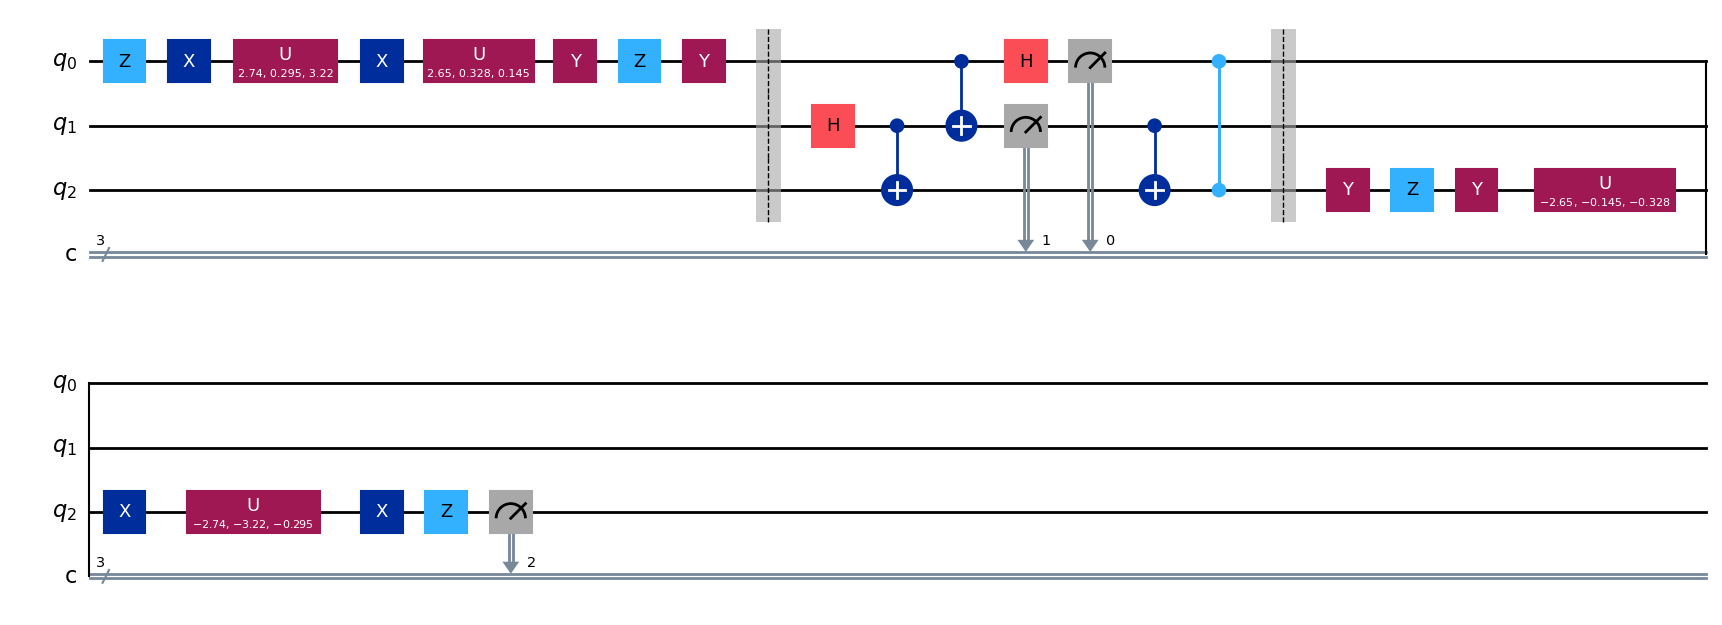

(1.0,
 {'011': 13, '001': 39, '000': 22, '010': 26},
 [('z',),
  ('x',),
  ('u', 2.74242111190765, 0.2954681077264298, 3.2180806690301775),
  ('x',),
  ('u', 2.6470162572641414, 0.32808857429676014, 0.1446839782072453),
  ('y',),
  ('z',),
  ('y',)],
 23)

In [272]:
teleportation_experiment(shots=100, num_gates=8, num_payload_qubits=0)